<a href="https://colab.research.google.com/github/saverin0/Advanced_Geospatial_Analysis/blob/main/04_geoviz_urban_data_nyc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 · Urban data acquisition and visualisation: Manhattan

Pulls four layers from the NYC Open Data portal (Socrata API), clips them to Manhattan and builds a
finished thematic map with legend, scale bar and north arrow.

| Layer | Dataset | ID |
|---|---|---|
| Borough outline | DSNY Zones | `ak2e-nbe8` |
| Parks | Parks Properties | `enfh-gkve` |
| Bike network | New York City Bike Routes | `mzxg-pwib` |
| Flood zones | Future Floodplain 2050s | `27ya-gqtm` |

All layers are fetched as GeoJSON directly from the API, so nothing has to be downloaded manually.
Basemap tiles come from Esri's free Canvas service (CartoDB tiles now require an API key).

In [ ]:
%pip install -q contextily mapclassify

In [ ]:
import io, os, math, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.enums import Resampling
from rasterio.plot import plotting_extent

DATA = Path("data")
DATA.mkdir(exist_ok=True)
FIG = Path("figures")
FIG.mkdir(exist_ok=True)


def read_preview(path, max_px=2000):
    """Read band 1 decimated so the longer side is <= max_px. Use this for plotting:
    imshow on the full 142-megapixel array needs several GB and kills small kernels."""
    with rasterio.open(path) as src:
        f = max(1, math.ceil(max(src.width, src.height) / max_px))
        arr = src.read(1, out_shape=(src.height // f, src.width // f),
                       resampling=Resampling.average, masked=True)
        return arr, plotting_extent(src)


def download(url, dest, unzip=False):
    """Download `url` to `dest` (file, or folder when unzip=True). Skips if already present."""
    dest = Path(dest)
    if dest.is_file() or (dest.is_dir() and any(dest.iterdir())):
        print("already present:", dest)
        return dest
    print("downloading:", url)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as r:
        payload = r.read()
    if unzip:
        dest.mkdir(parents=True, exist_ok=True)
        zipfile.ZipFile(io.BytesIO(payload)).extractall(dest)
    else:
        dest.write_bytes(payload)
    print(f"saved: {dest}  ({len(payload) / 1e6:.1f} MB)")
    return dest

import contextily as ctx
from xyzservices import TileProvider

# Esri Canvas tiles: free, no API key. Base layer without labels + reference layer with labels only.
ESRI_CANVAS = "https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/{layer}/MapServer/tile/{{z}}/{{y}}/{{x}}"
ESRI_ATTR = "Tiles (c) Esri - Esri, HERE, Garmin, (c) OpenStreetMap contributors, and the GIS User Community"
LIGHT_BASE = ctx.providers.Esri.WorldGrayCanvas
LIGHT_LABELS = TileProvider(name="Esri.WorldLightGrayReference",
                            url=ESRI_CANVAS.format(layer="World_Light_Gray_Reference"),
                            attribution=ESRI_ATTR, max_zoom=16)

## Acquire the layers

In [ ]:
SOCRATA = "https://data.cityofnewyork.us/resource/{id}.geojson?$limit=100000"

def fetch_layer(dataset_id, name):
    """Download a NYC Open Data dataset as GeoJSON (cached in data/) and load it."""
    path = download(SOCRATA.format(id=dataset_id), DATA / f"nyc_{name}.geojson")
    gdf = gpd.read_file(path)
    print(f"{name}: {len(gdf):,} features, CRS {gdf.crs}")
    return gdf

already present: data\nyc_dsny_zones.geojson


dsny_zones: 7 features, CRS EPSG:4326


<Axes: >

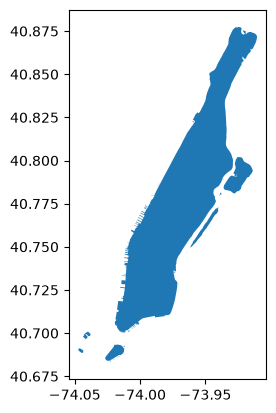

In [ ]:
gdf_admin = fetch_layer("ak2e-nbe8", "dsny_zones")
gdf_admin = gdf_admin[gdf_admin.zonename == "Manhattan"].copy()
gdf_admin.to_file(DATA / "manhattan_admin.geojson", driver="GeoJSON")
gdf_admin.plot()

already present: data\nyc_parks.geojson


parks: 2,061 features, CRS EPSG:4326
396 parks in Manhattan


<Axes: >

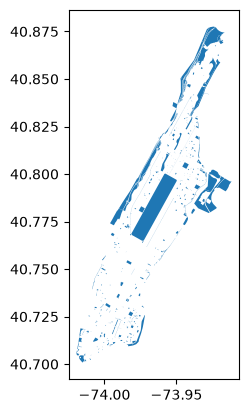

In [ ]:
gdf_parks = fetch_layer("enfh-gkve", "parks")
gdf_parks = gdf_parks[gdf_parks.borough == "M"].copy()
gdf_parks.to_file(DATA / "manhattan_parks.geojson", driver="GeoJSON")
print(len(gdf_parks), "parks in Manhattan")
gdf_parks.plot()

already present: data\nyc_bike_routes.geojson


bike_routes: 29,695 features, CRS EPSG:4326


7864 bike segments in Manhattan


<Axes: >

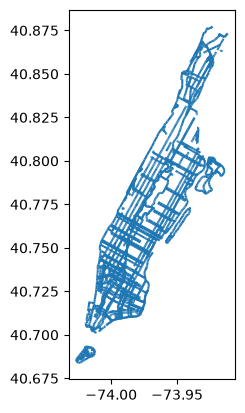

In [ ]:
gdf_bike = fetch_layer("mzxg-pwib", "bike_routes")
gdf_bike = gpd.overlay(gdf_bike, gdf_admin[["geometry"]], how="intersection")
gdf_bike.to_file(DATA / "manhattan_bike.geojson", driver="GeoJSON")
print(len(gdf_bike), "bike segments in Manhattan")
gdf_bike.plot()

already present: data\nyc_floodplain_2050s.geojson


floodplain_2050s: 10,611 features, CRS EPSG:4326


1140 flood polygons in Manhattan


<Axes: >

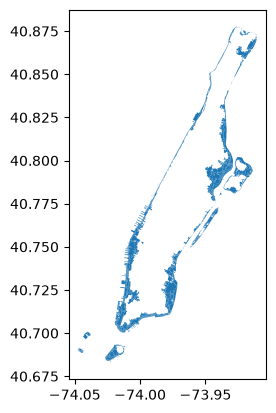

In [ ]:
gdf_flood = fetch_layer("27ya-gqtm", "floodplain_2050s")
gdf_flood = gpd.overlay(gdf_flood, gdf_admin[["geometry"]], how="intersection")
gdf_flood.to_file(DATA / "manhattan_flood.geojson", driver="GeoJSON")
print(len(gdf_flood), "flood polygons in Manhattan")
gdf_flood.plot()

## Quick composite

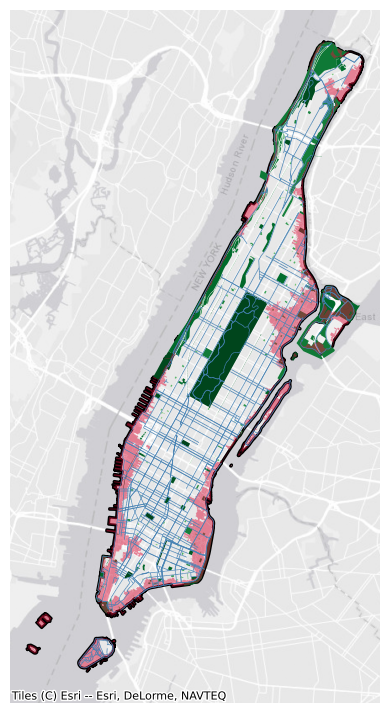

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9))
gdf_admin.to_crs(3857).plot(ax=ax, color="none", edgecolor="k", linewidth=2)
gdf_bike.to_crs(3857).plot(ax=ax, color="steelblue", linewidth=0.5)
gdf_parks.to_crs(3857).plot(ax=ax, cmap="Greens", column="acres")
gdf_flood.to_crs(3857).plot(ax=ax, color="crimson", alpha=0.5)
ctx.add_basemap(ax, source=LIGHT_BASE, zorder=0, crs=3857)
ax.set_axis_off()
plt.show()

## Finished map: legend, scale bar, north arrow

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from mapclassify import Quantiles

In [ ]:
admin = gdf_admin.to_crs(3857)
bike = gdf_bike.to_crs(3857)
parks = gdf_parks.to_crs(3857)
flood = gdf_flood.to_crs(3857)

parks["acres_num"] = pd.to_numeric(parks["acres"].astype(str).str.replace(",", "", regex=False), errors="coerce")
parks = parks.dropna(subset=["acres_num"])

scheme = Quantiles(parks["acres_num"], k=3)

def classify_tier(val):
    if val <= scheme.bins[0]:
        return "Small parks"
    elif val <= scheme.bins[1]:
        return "Medium parks"
    return "Large parks"

parks["tier"] = parks["acres_num"].apply(classify_tier)
parks["tier"].value_counts()

tier
Medium parks    132
Large parks     132
Small parks     132
Name: count, dtype: int64

In [ ]:
cmap = plt.cm.Greens
tier_colors = {
    "Small parks": cmap(0.3),
    "Medium parks": cmap(0.6),
    "Large parks": cmap(0.9),
}

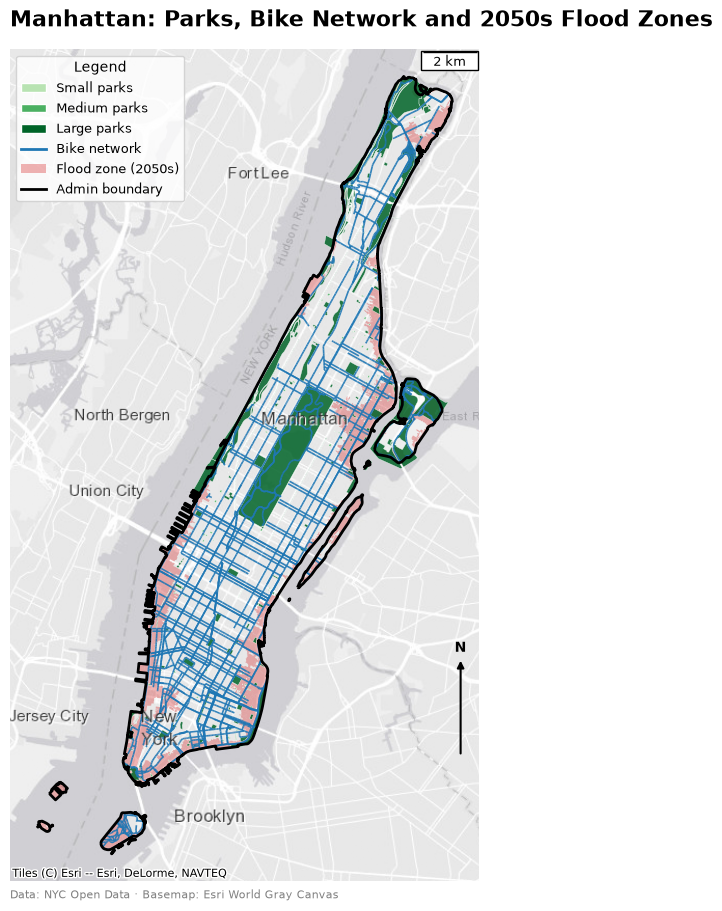

In [ ]:
fig, ax = plt.subplots(figsize=(9, 9), constrained_layout=True)
ax.set_axis_off()

# Map extent with padding
xmin, ymin, xmax, ymax = admin.total_bounds
pad = 1000
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

# Basemap (no labels below, labels on top)
ctx.add_basemap(ax, source=LIGHT_BASE, crs=3857, zorder=0)
ctx.add_basemap(ax, source=LIGHT_LABELS, crs=3857, zorder=4, attribution=False)

# Flood zones
flood.plot(ax=ax, color="#d62728", alpha=0.35, linewidth=0, zorder=1)

# Parks by size tier
parks.plot(ax=ax, color=parks["tier"].map(tier_colors), linewidth=0.3,
           edgecolor="white", alpha=0.85, zorder=2)
park_handles = [Patch(facecolor=c, edgecolor="white", label=l) for l, c in tier_colors.items()]

# Bike network and admin boundary
bike.plot(ax=ax, color="#1f77b4", linewidth=1.2, alpha=0.9, zorder=3)
admin.boundary.plot(ax=ax, color="black", linewidth=2, zorder=5)
other_handles = [
    Line2D([0], [0], color="#1f77b4", lw=2, label="Bike network"),
    Patch(facecolor="#d62728", alpha=0.35, edgecolor="none", label="Flood zone (2050s)"),
    Line2D([0], [0], color="black", lw=2, label="Admin boundary"),
]
ax.legend(handles=park_handles + other_handles, loc="upper left", frameon=True, title="Legend", fontsize=9)

# Scale bar
width_m = xmax - xmin
for target in (20000, 10000, 5000, 2000, 1000):
    if width_m / target >= 6:
        length = target
        break
else:
    length = 1000
sb = AnchoredSizeBar(ax.transData, length, f"{int(length / 1000)} km", loc="upper right",
                     pad=0.1, frameon=True, color="black", size_vertical=4,
                     fontproperties=fm.FontProperties(size=9))
ax.add_artist(sb)

# North arrow: shaft from the lower point up to the "N" label
ax.annotate("N", xy=(0.96, 0.15), xytext=(0.96, 0.28), xycoords="axes fraction",
            textcoords="axes fraction", ha="center", va="center", fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="<|-", color="black", lw=1.5))

ax.set_title("Manhattan: Parks, Bike Network and 2050s Flood Zones", loc="left",
             fontsize=16, weight="bold", pad=6)
ax.text(0.0, -0.01, "Data: NYC Open Data · Basemap: Esri World Gray Canvas", transform=ax.transAxes,
        fontsize=8, color="gray", va="top")
plt.savefig(FIG / "04_manhattan_map.png", dpi=150, bbox_inches="tight")
plt.show()